In [6]:
# @title 물성라이브러리 설치 code
!pip install cantera
!pip install CoolProp
import cantera as ct
print(ct.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.2 MB/s eta 0:00:00
3.2.0


In [44]:
def C_to_K(T_C):
    # 섭씨 온도를 켈빈 온도로 변환
    return T_C + 273.15

def bar_to_Pa(P_bar):
    # bar 단위를 파스칼(Pa)로 변환
    return P_bar * 1e5

# @title 조건 입력 code
params = {

    "v_lng_tank_m3_per_hr": 550.0, # LNG 체적 유량 (m3/h) - 입력
    "v_bog_tank_m3_per_hr": 18100.0, # BOG 체적 유량 (m3/h) - 입력

    # LNG 저장 탱크 및 실제 펌프 입구 조건
    "T_lng_tank": C_to_K(-162.0),
    "P_lng_tank": bar_to_Pa(5.0),

    # LNG 2차 펌프 출구 압력
    "P_lng_high": bar_to_Pa(80.0),

    # LNG 주입 유량 (디슈퍼히터에서 BOG와 혼합되는 LNG 양)
    "v_lng_injection_m3_per_hr": 16.0, # (m3/h) - 입력. 펌프 출구 조건의 LNG 밀도 기준.

    # 탱크로부터 나오는 BOG 조건 입력
    "T_bog_tank": C_to_K(-100.0),
    "P_bog_tank": bar_to_Pa(1.157),
    "P_bog_comp_out": bar_to_Pa(9.91), # 단일 BOG 압축기의 목표 출구 압력

    # 설비 작동 성능 입력
    "pump_eta": 0.70,
    "comp_eta": 0.665,
    "desuperheater_effectiveness": 0.70 # (이제 직접 열교환이 아닌, 혼합 유량 비율로 해석됩니다.)
}

In [41]:
# @title Process modeling
import os
import pandas as pd
from CoolProp.CoolProp import PropsSI

methane_mass_fraction_bog = 0.79 # BOG용: 메탄 79%
nitrogen_mass_fraction_bog = 0.21 # BOG용: 질소 21%
# FLUID = f"Methane[{methane_mass_fraction_bog}]&Nitrogen[{nitrogen_mass_fraction_bog}]" # BOG용 유체

# LNG는 이제 순수 메탄으로 직접 정의됩니다.
methane_mass_fraction_lng = 1.0 # LNG용: 메탄 100%
nitrogen_mass_fraction_lng = 0.0 # LNG용: 질소 0%
FLUID_LNG = 'Methane' # LNG용 유체 (순수 메탄)

# 조성 문자열 동적 생성
composition_str_bog = f"메탄 {int(methane_mass_fraction_bog*100)}%, 질소 {int(nitrogen_mass_fraction_bog*100)}%"
composition_str_lng = f"메탄 {int(methane_mass_fraction_lng*100)}%, 질소 {int(nitrogen_mass_fraction_lng*100)}%"

def C_to_K(T_C):
    # 섭씨 온도를 켈빈 온도로 변환
    return T_C + 273.15

def K_to_C(T_K):
    # 켈빈 온도를 섭씨 온도로 변환
    return T_K - 273.15

def bar_to_Pa(P_bar):
    # bar 단위를 파스칼(Pa)로 변환
    return P_bar * 1e5

def Pa_to_bar(P_Pa):
    # 파스칼(Pa) 단위를 bar로 변환
    return P_Pa / 1e5

# =====================================================
# 1. CoolProp 속성 도우미 함수들
# =====================================================

def h_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔탈피(Hmass) 계산
    try:
        return PropsSI("Hmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Hmass", "T", T + 0.1, "P", P, fluid)

def s_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 엔트로피(Smass) 계산
    try:
        return PropsSI("Smass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Smass", "T", T + 0.1, "P", P, fluid)

def T_Ph(P, h, fluid):
    # 압력(P)과 질량 엔탈피(h)로 온도(T) 계산
    return PropsSI("T", "P", P, "Hmass", h, fluid)

def h_PS(P, s, fluid):
    # 압력(P)과 질량 엔트로피(s)로 질량 엔탈피(Hmass) 계산 (등엔트로피 과정)
    return PropsSI("Hmass", "P", P, "Smass", s, fluid)

def rho_TP(T, P, fluid):
    # 온도(T)와 압력(P)으로 질량 밀도(Dmass) 계산
    try:
        return PropsSI("Dmass", "T", T, "P", P, fluid)
    except ValueError:
        # 오류 발생 시 약간의 온도 보정
        return PropsSI("Dmass", "T", T + 0.1, "P", P, fluid)

# =====================================================
# 2. 컴포넌트 모델
# =====================================================

def liquid_pump(m_dot, T_in, P_in, P_out, eta=0.75, fluid=FLUID_LNG):
    # 액체 펌프 모델
    h_in = h_TP(T_in, P_in, fluid)
    rho = rho_TP(T_in, P_in, fluid)

    if rho < 100.0:
        # 펌프 입구 밀도가 너무 낮으면 오류 발생 (액체가 아닌 증기/이상 상태일 가능성)
        raise ValueError(
            f"액체 펌프 입구 밀도가 너무 낮습니다 ({rho:.3f} kg/m3). "
            "입구는 증기/이상 상태일 가능성이 높습니다. "
            "펌프 입구 압력을 높이거나 펌프 입구 온도를 낮추십시오."
        )

    # 펌프 일 (엔탈피 변화)
    dh = (P_out - P_in) / rho / eta
    h_out = h_in + dh
    T_out = T_Ph(P_out, h_out, fluid)
    W = m_dot * dh

    return {
        "T_out": T_out, # 출구 온도
        "P_out": P_out, # 출구 압력
        "h_out": h_out, # 출구 엔탈피
        "W": W,         # 펌프 동력
        "rho_in": rho,  # 입구 밀도
    }

def compressor(m_dot, T_in, P_in, P_out, eta=0.75, fluid=None):
    # 압축기 모델
    if fluid is None:
        raise ValueError("Compressor fluid cannot be None.")

    if m_dot <= 0:
        # 질량 유량이 없으면 압축기 동력은 0
        return {
            "T_out": T_in,
            "P_out": P_out,
            "h_out": h_TP(T_in, P_out, fluid),
            "W": 0.0,
        }

    h_in = h_TP(T_in, P_in, fluid)
    s_in = s_TP(T_in, P_in, fluid)
    # 등엔트로피 출구 엔탈피
    h_out_s = h_PS(P_out, s_in, fluid)
    # 실제 출구 엔탈피 (효율 반영)
    h_out = h_in + (h_out_s - h_in) / eta
    T_out = T_Ph(P_out, h_out, fluid)
    # 압축기 동력
    W = m_dot * (h_out - h_in)

    return {
        "T_out": T_out,
        "P_out": P_out,
        "h_out": h_out,
        "W": W,
    }

def mixer(m_dot1, T1, P1, h1, comp1_methane_mf, comp1_nitrogen_mf,
          m_dot2, T2, P2, h2, comp2_methane_mf, comp2_nitrogen_mf,
          P_out=None):
    """
    두 스트림을 혼합하는 모델. 질량 및 에너지 균형을 수행합니다.
    P_out이 지정되지 않으면, 더 높은 압력을 가정합니다.
    """

    # 결과 압력 (더 높은 압력 또는 지정된 압력 사용)
    P_mix = P_out if P_out is not None else max(P1, P2)

    # 총 질량 유량
    m_dot_mix = m_dot1 + m_dot2

    if m_dot_mix == 0:
        return {
            'T_out': T1 if m_dot1 > 0 else T2, # 둘 중 하나가 있으면 그 온도를 반환
            'P_out': P_mix,
            'h_out': h1 if m_dot1 > 0 else h2,
            'fluid_mix_str': FLUID_LNG if m_dot1 > 0 else f"Methane[{comp2_methane_mf}]&Nitrogen[{comp2_nitrogen_mf}]",
            'comp_mix_methane_mf': comp1_methane_mf if m_dot1 > 0 else comp2_methane_mf,
            'comp_mix_nitrogen_mf': comp1_nitrogen_mf if m_dot1 > 0 else comp2_nitrogen_mf,
            'Q': 0.0, # 열 전달 없음
        }

    # 총 엔탈피 균형
    h_mix = (m_dot1 * h1 + m_dot2 * h2) / m_dot_mix

    # 새로운 조성 계산
    methane_mass = m_dot1 * comp1_methane_mf + m_dot2 * comp2_methane_mf
    nitrogen_mass = m_dot1 * comp1_nitrogen_mf + m_dot2 * comp2_nitrogen_mf

    comp_mix_methane_mf = methane_mass / m_dot_mix
    comp_mix_nitrogen_mf = nitrogen_mass / m_dot_mix

    # 혼합 유체 CoolProp 문자열 생성
    fluid_mix_str = f"Methane[{comp_mix_methane_mf:.4f}]&Nitrogen[{comp_mix_nitrogen_mf:.4f}]"

    # 혼합 온도 계산 (P_mix와 h_mix로)
    T_mix = T_Ph(P_mix, h_mix, fluid_mix_str)

    return {
        'T_out': T_mix,             # 혼합 스트림 출구 온도
        'P_out': P_mix,             # 혼합 스트림 출구 압력
        'h_out': h_mix,             # 혼합 스트림 출구 엔탈피
        'fluid_mix_str': fluid_mix_str, # 혼합 스트림 조성 문자열
        'comp_mix_methane_mf': comp_mix_methane_mf,
        'comp_mix_nitrogen_mf': comp_mix_nitrogen_mf,
        'Q': 0.0,                   # 혼합기 자체의 열 전달은 0
    }

def heat_exchanger_effectiveness(
    m_cold,
    T_cold_in,
    P_cold,
    fluid_cold,
    m_hot,
    T_hot_in,
    P_hot,
    fluid_hot,
    effectiveness=0.60,
    min_delta_T=3.0,
):
    """
    일반적인 열교환기 유용도(effectiveness) 모델.
    뜨거운 스트림이 차가운 스트림에 열을 전달합니다.
    """
    if m_hot <= 0 or effectiveness <= 0:
        # 뜨거운 유량 또는 유용도가 0 이하면 열 전달 없음
        return {
            "Q": 0.0,
            "T_cold_out": T_cold_in,
            "h_cold_out": h_TP(T_cold_in, P_cold, fluid_cold),
            "T_hot_out": T_hot_in,
            "h_hot_out": h_TP(T_hot_in, P_hot, fluid_hot),
        }

    h_hot_in = h_TP(T_hot_in, P_hot, fluid_hot)
    h_cold_in = h_TP(T_cold_in, P_cold, fluid_cold)
    # 최소 접근 온도 차이를 고려한 뜨거운 스트림의 최소 온도
    T_hot_min = T_cold_in + min_delta_T
    h_hot_min = h_TP(T_hot_min, P_hot, fluid_hot)

    # 최대 가능한 열량 (뜨거운 스트림 기준)
    Q_max_hot = m_hot * max(h_hot_in - h_hot_min, 0.0)
    # 실제 열 전달량 (유용도 반영)
    Q = effectiveness * Q_max_hot

    # 출구 엔탈피 계산
    h_hot_out = h_hot_in - Q / m_hot
    h_cold_out = h_cold_in + Q / m_cold

    # 출구 온도 계산
    T_hot_out = T_Ph(P_hot, h_hot_out, fluid_hot)
    T_cold_out = T_Ph(P_cold, h_cold_out, fluid_cold)

    return {
        "Q": Q,                             # 열 전달량
        "T_cold_out": T_cold_out,         # 차가운 스트림 출구 온도
        "h_cold_out": h_cold_out,         # 차가운 스트림 출구 엔탈피
        "T_hot_out": T_hot_out,           # 뜨거운 스트림 출구 온도
        "h_hot_out": h_hot_out,           # 뜨거운 스트림 출구 엔탈피
    }

def set_stream_temperature(m_dot, T_in, P, T_target, fluid):
    """
    히터/쿨러를 적용하여 동일 압력에서 스트림 온도를 설정합니다.
    양의 Q는 스트림에 열이 추가됨을 의미합니다.
    """
    h_in = h_TP(T_in, P, fluid)
    h_out = h_TP(T_target, P, fluid)
    # 필요한 열량
    Q = m_dot * (h_out - h_in)

    return {
        "Q": Q,
        "T_out": T_target,
        "P_out": P,
        "h_out": h_out,
    }


# =====================================================
# 3. 다단 HPC 모델 (사용하지 않음)
# =====================================================

def get_hpc_stage_pressures(P_in, P_out, n_stages):
    """
    균등 압력비 단계.
    경계 압력: [P0, P1, ..., Pn]을 반환합니다.
    """
    pr_stage = (P_out / P_in) ** (1.0 / n_stages)
    pressures = [P_in]
    for _ in range(n_stages):
        pressures.append(pressures[-1] * pr_stage)
    pressures[-1] = P_out # 마지막 압력을 P_out으로 강제 설정하여 부동 소수점 오차 방지
    return pressures


def multistage_hpc_no_intercooling(m_dot, T_in, P_in, P_out, eta=0.75, n_stages=3, fluid=None):
    # 중간 냉각 없는 다단 고압 압축기(HPC) 모델
    # 이 함수는 현재 간소화된 모델에서 사용되지 않습니다.
    if fluid is None:
        raise ValueError("Compressor fluid cannot be None.")

    pressures = get_hpc_stage_pressures(P_in, P_out, n_stages)
    T = T_in
    W_total = 0.0
    stage_results = []

    for i in range(n_stages):
        T_stage_in = T
        comp = compressor(m_dot, T_stage_in, pressures[i], pressures[i + 1], eta, fluid=fluid)
        W_total += comp["W"]
        T = comp["T_out"]

        stage_results.append({
            "stage": i + 1,
            "P_in": pressures[i],
            "P_out": pressures[i + 1],
            "T_in": T_stage_in,
            "T_out": comp["T_out"],
            "W": comp["W"],
        })

    return {
        "T_out": T,
        "P_out": P_out,
        "W": W_total,
        "stages": stage_results,
    }


# =====================================================
# 4. 전체 공정 모델 헬퍼 함수
# =====================================================

def _assemble_simplified_results(
    params,
    m_lng,
    m_bog_total,
    vol_lng_m3_per_hr,
    rho_lng_tank,
    vol_bog_m3_per_hr,
    rho_bog_tank,
    pump_results,
    T_lng_after_pump_calc,
    P_lng_after_pump,
    m_lng_injection,
    m_mixed_total,
    T_mixed_out,
    P_mixed_out,
    fluid_mixed_str,
    comp_mixed_methane_mf,
    comp_mixed_nitrogen_mf,
    comp_bog_results,
    T_mixed_comp_out,
    P_mixed_comp_out
):

    # 총 전력 및 열량 계산
    total_power_mw = (pump_results["W"] + comp_bog_results["W"]) / 1e6
    pump_out_heating_duty_mw = 0.0 # No initial heating
    # desuperheater_duty_mw = Q_desuperheater / 1e6 # 이제 열교환기가 아님

    # 혼합 유체의 조성 문자열
    composition_str_mixed = f"메탄 {int(comp_mixed_methane_mf*100)}%, 질소 {int(comp_mixed_nitrogen_mf*100)}%"

    return {
        "LNG_TANK_VOL_FLOW_M3_PER_HR": vol_lng_m3_per_hr, # LNG 탱크 체적 유량 (입력)
        "LNG_TANK_RHO_KG_PER_M3": rho_lng_tank, # LNG 탱크 밀도 (계산)
        "LNG_MASS_FLOW_KG_PER_S": m_lng, # LNG 질량 유량 (계산)

        "BOG_TANK_VOL_FLOW_M3_PER_HR": vol_bog_m3_per_hr, # BOG 탱크 체적 유량 (입력)
        "BOG_TANK_RHO_KG_PER_M3": rho_bog_tank, # BOG 탱크 밀도 (계산)
        "BOG_TOTAL_MASS_FLOW_KG_PER_S": m_bog_total, # BOG 질량 유량 (계산)

        "LNG_TANK_T_C": K_to_C(params["T_lng_tank"]), # LNG 탱크 온도 (섭씨)
        "LNG_TANK_P_BAR": Pa_to_bar(params["P_lng_tank"]), # LNG 탱크 압력 (bar)
        "LNG_PUMP_OUT_CALC_T_C": K_to_C(T_lng_after_pump_calc), # LNG 펌프 출구 계산된 온도 (섭씨)
        "LNG_PUMP_OUT_P_BAR": Pa_to_bar(P_lng_after_pump), # LNG 펌프 출구 압력 (bar)
        # "LNG_PUMP_OUT_HEATED_T_C": K_to_C(T_lng_after_desuperheater), # LNG 디슈퍼히터 출구 온도 (섭씨)
        "LNG_PUMP_OUT_HEATING_DUTY_MW": pump_out_heating_duty_mw, # LNG 펌프 출구 가열 열량 (MW)

        "BOG_TANK_T_C": K_to_C(params["T_bog_tank"]),     # BOG 탱크 온도 (섭씨)
        "BOG_TANK_P_BAR": Pa_to_bar(params["P_bog_tank"]), # BOG 탱크 압력 (bar)
        # "BOG_DESUPERHEATER_OUT_T_C": K_to_C(T_bog_after_desuperheater), # BOG 디슈퍼히터 출구 온도 (섭씨)
        "MIXED_STREAM_T_C": K_to_C(T_mixed_out),       # 혼합 스트림 출구 온도 (섭씨)
        "MIXED_STREAM_P_BAR": Pa_to_bar(P_mixed_out), # 혼합 스트림 출구 압력 (bar)
        "MIXED_STREAM_MASS_FLOW_KG_PER_S": m_mixed_total, # 혼합 스트림 질량 유량 (kg/s)
        "MIXED_STREAM_FLUID_STR": fluid_mixed_str, # 혼합 스트림 조성 문자열
        "MIXED_STREAM_COMP_STR": composition_str_mixed, # 혼합 스트림 조성 문자열 (표시용)

        "COMPRESSOR_OUT_T_C": K_to_C(T_mixed_comp_out),       # 압축기 출구 온도 (섭씨) (이제 혼합 스트림)
        "COMPRESSOR_OUT_P_BAR": Pa_to_bar(P_mixed_comp_out), # 압축기 출구 압력 (bar)

        "DESUPERHEATER_DUTY_MW": 0.0,    # 디슈퍼히터 열량 (MW) - 이제 혼합기이므로 열교환 아님
        "LNG_PUMP_POWER_MW": pump_results["W"] / 1e6,              # LNG 펌프 동력 (MW)
        "BOG_COMP_POWER_MW": comp_bog_results["W"] / 1e6,          # BOG 압축기 동력 (MW)
        "TOTAL_POWER_MW": total_power_mw,                  # 총 동력 (MW)

        "INJECTED_LNG_MASS_FLOW_KG_PER_S": m_lng_injection,
    }

def simulate_process(params):
    # 주요 매개변수 추출
    v_lng_tank_m3_per_hr = params["v_lng_tank_m3_per_hr"]
    v_bog_tank_m3_per_hr = params["v_bog_tank_m3_per_hr"]
    v_lng_injection_m3_per_hr = params["v_lng_injection_m3_per_hr"]

    # 명확성을 위한 주요 매개변수 추출
    P_lng_tank = params["P_lng_tank"]
    T_lng_tank = params["T_lng_tank"]
    P_lng_high = params["P_lng_high"]

    P_bog_tank = params["P_bog_tank"]
    T_bog_tank = params["T_bog_tank"]
    P_bog_comp_out_target = params["P_bog_comp_out"]

    # LNG 탱크 밀도 계산 및 질량 유량 변환
    rho_lng_tank = rho_TP(T_lng_tank, P_lng_tank, FLUID_LNG)
    m_lng = v_lng_tank_m3_per_hr * rho_lng_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s

    # BOG 탱크 밀도 계산 및 질량 유량 변환
    # BOG는 초기 CoolProp FLUID 정의 사용
    fluid_bog_tank_str = f"Methane[{methane_mass_fraction_bog}]&Nitrogen[{nitrogen_mass_fraction_bog}]"
    rho_bog_tank = rho_TP(T_bog_tank, P_bog_tank, fluid_bog_tank_str)
    m_bog_total = v_bog_tank_m3_per_hr * rho_bog_tank / 3600.0 # m3/h * kg/m3 / 3600 s/h = kg/s


    # 1. LNG 펌프
    pump = liquid_pump(
        m_dot=m_lng,
        T_in=T_lng_tank,
        P_in=P_lng_tank,
        P_out=P_lng_high,
        eta=params["pump_eta"],
        fluid=FLUID_LNG
    )

    T_lng_after_pump_calc = pump["T_out"]
    P_lng_after_pump = pump["P_out"]
    h_lng_after_pump_calc = pump["h_out"]

    # 펌프 출구 초기 가열 (디슈퍼히터 이전) 제거됨.
    # LNG 펌프 출구 온도가 바로 디슈퍼히터로 들어갑니다.
    # Q_lng_pump_out_heating = 0.0 # No heating duty


    # 2. 디슈퍼히터 (이제 혼합기로 모델링)
    # 주입되는 LNG의 질량 유량 계산 (펌프 출구 밀도 기준)
    rho_lng_at_pump_out = rho_TP(T_lng_after_pump_calc, P_lng_after_pump, FLUID_LNG)
    m_lng_injection = v_lng_injection_m3_per_hr * rho_lng_at_pump_out / 3600.0

    # BOG 스트림의 엔탈피 (BOG 탱크 조건)
    h_bog_tank = h_TP(T_bog_tank, P_bog_tank, fluid_bog_tank_str)

    # Mixer (LNG 주입 스트림과 BOG 스트림 혼합)
    mixer_results = mixer(
        m_dot1=m_lng_injection,
        T1=T_lng_after_pump_calc,
        P1=P_lng_after_pump,
        h1=h_lng_after_pump_calc,
        comp1_methane_mf=methane_mass_fraction_lng,
        comp1_nitrogen_mf=nitrogen_mass_fraction_lng,
        m_dot2=m_bog_total,
        T2=T_bog_tank,
        P2=P_bog_tank,
        h2=h_bog_tank,
        comp2_methane_mf=methane_mass_fraction_bog,
        comp2_nitrogen_mf=nitrogen_mass_fraction_bog,
        P_out=P_bog_tank # 혼합기 출구 압력은 BOG 탱크 압력과 동일하다고 가정 (압력 강하 무시)
    )

    T_mixed_out = mixer_results["T_out"]
    P_mixed_out = mixer_results["P_out"]
    h_mixed_out = mixer_results["h_out"]
    fluid_mixed_str = mixer_results["fluid_mix_str"]
    comp_mixed_methane_mf = mixer_results["comp_mix_methane_mf"]
    comp_mixed_nitrogen_mf = mixer_results["comp_mix_nitrogen_mf"]
    m_mixed_total = mixer_results["m_dot_mix"]
    Q_desuperheater = mixer_results["Q"] # Mixer Q is 0, just to keep the variable name consistent with previous HE


    # 3. 압축기 (이제 혼합 스트림을 압축)
    comp_bog_results = compressor(
        m_dot=m_mixed_total,
        T_in=T_mixed_out, # 혼합 스트림 온도가 압축기 입구 온도
        P_in=P_mixed_out, # 혼합 스트림 압력이 압축기 입구 압력
        P_out=P_bog_comp_out_target,
        eta=params["comp_eta"],
        fluid=fluid_mixed_str # 혼합 스트림 조성 사용
    )
    T_mixed_comp_out = comp_bog_results["T_out"]
    P_mixed_comp_out = comp_bog_results["P_out"]


    # 4. 결과 취합
    return _assemble_simplified_results(
        params=params,
        m_lng=m_lng,
        m_bog_total=m_bog_total,
        vol_lng_m3_per_hr=v_lng_tank_m3_per_hr,
        rho_lng_tank=rho_lng_tank,
        vol_bog_m3_per_hr=v_bog_tank_m3_per_hr,
        rho_bog_tank=rho_bog_tank,
        pump_results=pump,
        T_lng_after_pump_calc=T_lng_after_pump_calc,
        P_lng_after_pump=P_lng_after_pump,
        m_lng_injection=m_lng_injection,
        m_mixed_total=m_mixed_total,
        T_mixed_out=T_mixed_out,
        P_mixed_out=P_mixed_out,
        fluid_mixed_str=fluid_mixed_str,
        comp_mixed_methane_mf=comp_mixed_methane_mf,
        comp_mixed_nitrogen_mf=comp_mixed_nitrogen_mf,
        comp_bog_results=comp_bog_results,
        T_mixed_comp_out=T_mixed_comp_out,
        P_mixed_comp_out=P_mixed_comp_out
    )

In [42]:
# @title 위상 확인 코드
import pandas as pd
import CoolProp.CoolProp as CP
from CoolProp.CoolProp import PropsSI

def get_phase_string(T_C, P_bar, fluid):
    T_K = C_to_K(T_C)
    P_Pa = bar_to_Pa(P_bar)

    is_mixture = '&' in fluid

    try:
        # Attempt 1: Get phase string directly from CoolProp (most reliable if it works)
        raw_phase_output_str = CP.PropsSI('Phase_ALPHANUMERIC', 'T', T_K, 'P', P_Pa, fluid)

        # Standard processing of CoolProp's alphanumeric phase
        if raw_phase_output_str == 'liquid': return '액체'
        elif raw_phase_output_str == 'gas': return '기체'
        elif raw_phase_output_str == 'supercritical': return '초임계'
        elif raw_phase_output_str == 'critical_point': return '임계점'
        elif raw_phase_output_str == 'two_phase':
            try:
                Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                return f'기액 이중상 (건도: {Q:.2f})'
            except ValueError:
                return '기액 이중상 (건도 확인 불가)'
        elif raw_phase_output_str == 'SupercriticalGas_Phase': return '초임계 (기체상)'
        elif raw_phase_output_str == 'SupercriticalLiquid_Phase': return '초임계 (액체상)'
        elif raw_phase_output_str == 'Subcritical_Gas': return '기체 (아임계)'
        elif raw_phase_output_str == 'Subcritical_Liquid': return '액체 (아임계)'
        else:
            return f'알 수 없음 (CoolProp Phase_ALPHANUMERIC: {raw_phase_output_str})'

    except ValueError as e:
        # If Phase_ALPHANUMERIC fails, try alternative methods.
        # This often happens when CoolProp struggles with internal saturation curve calculations.

        if is_mixture:
            # For mixtures, try bubble/dew point comparison
            try:
                T_bubble_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 0, fluid) # Saturated liquid temperature (bubble point)
                T_dew_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 1, fluid)    # Saturated vapor temperature (dew point)

                if T_K < T_bubble_K:
                    return '액체 (과냉각)'
                elif T_K > T_dew_K:
                    return '기체 (과열)'
                elif T_bubble_K <= T_K <= T_dew_K:
                    try:
                        Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                        return f'기액 이중상 (건도: {Q:.2f})'
                    except ValueError:
                        return '기액 이중상 (건도 확인 불가 - 혼합물)'
                else:
                    return f'알 수 없음 (혼합물 상 평형 실패)' # Should not reach here if bubble/dew are found
            except ValueError as mix_e:
                # If bubble/dew point calculations also fail, return detailed mixture error
                return f'알 수 없음 (CoolProp 혼합물 오류: 유체 "{fluid}"에 대해 T={K_to_C(T_K):.2f}°C, P={Pa_to_bar(P_Pa):.2f} bar에서 상 판단 실패 - {mix_e})'
            except Exception as mix_e_general:
                return f'오류 발생 (혼합물): {type(mix_e_general).__name__} (상 판단 중 일반 오류)'
        else: # Not a mixture (pure fluid)
            try:
                # For pure fluids, explicitly check saturation temperatures first
                T_sat_Q0_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 0, fluid)
                T_sat_Q1_K = CP.PropsSI('T', 'P', P_Pa, 'Q', 1, fluid)

                if T_K < T_sat_Q0_K:
                    return '액체 (과냉각)'
                elif T_K > T_sat_Q1_K:
                    return '기체 (과열)'
                elif T_sat_Q0_K <= T_K <= T_sat_Q1_K:
                    try:
                        Q = CP.PropsSI('Q', 'T', T_K, 'P', P_Pa, fluid)
                        return f'기액 이중상 (건도: {Q:.2f})'
                    except ValueError:
                        return '기액 이중상 (건도 확인 불가 - 순수 유체)'
                else:
                    # This case should ideally not be reached for pure fluids, unless P is above critical pressure
                    # and T is below critical temperature (subcooled liquid region) or other complex scenarios.
                    # Fallback to critical point check if this happens.
                    pass # Proceed to critical point check below

            except ValueError as pure_sat_e:
                # If saturation properties also fail (e.g., supercritical, or P/T out of bounds for sat func)
                # Proceed to critical point check for pure fluids.
                pass # Proceed to critical point check below

            # Fallback for pure fluid: critical point check and density heuristic
            try:
                Tc_K = CP.PropsSI('Tcrit', fluid)
                Pc_Pa = CP.PropsSI('Pcrit', fluid)

                if T_K >= Tc_K and P_Pa >= Pc_Pa:
                    return '초임계'
                elif T_K > Tc_K and P_Pa < Pc_Pa:
                    return '기체 (과열/초임계 유사)'
                elif T_K < Tc_K and P_Pa > Pc_Pa:
                    return '액체 (과냉각/초임계 유사)'
                else:
                    # Final fallback to density heuristic if all other methods failed for pure fluid.
                    rho = CP.PropsSI('Dmass', 'T', T_K, 'P', P_Pa, fluid)
                    if rho > 200: # Arbitrary threshold, needs domain knowledge for specific fluids
                        return f'액체 (밀도 기반 추정: {rho:.2f} kg/m³)'
                    elif rho < 50: # Arbitrary threshold
                        return f'기체 (밀도 기반 추정: {rho:.2f} kg/m³)'
                    else:
                        return f'알 수 없음 (밀도 {rho:.2f} kg/m³로 위상 판단 어려움)'

            except ValueError as inner_e:
                return f'알 수 없음 (CoolProp 속성 계산 실패: {fluid} at T={K_to_C(T_K):.2f}°C, P={Pa_to_bar(P_Pa):.2f} bar - {inner_e})'
            except Exception as inner_e_general:
                return f'오류 발생 (상 판단 중): {type(inner_e_general).__name__} (내부 CoolProp 호출 실패 - {inner_e_general})'

    except Exception as e:
        return f'오류 발생: {type(e).__name__} (일반적인 오류 - {e})'


In [43]:
# @title
results = simulate_process(params)

data_points = []

# LNG Stream
# 1. LNG 탱크
data_points.append({
    '위치': 'LNG 탱크',
    '온도 [°C]': f"{results['LNG_TANK_T_C']:.2f} (입력)",
    '압력 [bar]': f"{results['LNG_TANK_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{results['LNG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (입력)",
    '밀도 [kg/m³]': f"{results['LNG_TANK_RHO_KG_PER_M3']:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['LNG_TANK_T_C'], results['LNG_TANK_P_BAR'], FLUID_LNG),
    '조성': composition_str_lng,
    '다음 위치': 'LNG 펌프 출구'
})

# 2. LNG 펌프 출구
rho_lng_pump_out_calc = rho_TP(C_to_K(results['LNG_PUMP_OUT_CALC_T_C']), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    '위치': 'LNG 펌프 출구',
    '온도 [°C]': f"{results['LNG_PUMP_OUT_CALC_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_pump_out_calc * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_lng_pump_out_calc:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['LNG_PUMP_OUT_CALC_T_C'], results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    '조성': composition_str_lng,
    '다음 위치': 'LNG 디슈퍼히터 출구'
})

# 3. LNG 디슈퍼히터 출구
rho_lng_desuperheater_out = rho_TP(C_to_K(results['LNG_PUMP_OUT_HEATED_T_C']), bar_to_Pa(results['LNG_PUMP_OUT_P_BAR']), FLUID_LNG)
data_points.append({
    '위치': 'LNG 디슈퍼히터 출구',
    '온도 [°C]': f"{results['LNG_PUMP_OUT_HEATED_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['LNG_PUMP_OUT_P_BAR']:.2f} (입력)", # 압력 강하 없다고 가정
    '체적 유량 [m³/h]': f"{(results['LNG_MASS_FLOW_KG_PER_S'] / rho_lng_desuperheater_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_lng_desuperheater_out:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['LNG_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['LNG_PUMP_OUT_HEATED_T_C'], results['LNG_PUMP_OUT_P_BAR'], FLUID_LNG),
    '조성': composition_str_lng,
    '다음 위치': '(LNG 최종 스코프)'
})

# BOG Stream
# 4. BOG 탱크
data_points.append({
    '위치': 'BOG 탱크',
    '온도 [°C]': f"{results['BOG_TANK_T_C']:.2f} (입력)",
    '압력 [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (입력)",
    '체적 유량 [m³/h]': f"{results['BOG_TANK_VOL_FLOW_M3_PER_HR']:.2f} (입력)",
    '밀도 [kg/m³]': f"{results['BOG_TANK_RHO_KG_PER_M3']:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['BOG_TANK_T_C'], results['BOG_TANK_P_BAR'], FLUID),
    '조성': composition_str_bog,
    '다음 위치': 'BOG 디슈퍼히터 입구'
})

# 5. BOG 디슈퍼히터 출구
rho_bog_desuperheater_out = rho_TP(C_to_K(results['BOG_DESUPERHEATER_OUT_T_C']), bar_to_Pa(results['BOG_TANK_P_BAR']), FLUID)
data_points.append({
    '위치': 'BOG 디슈퍼히터 출구',
    '온도 [°C]': f"{results['BOG_DESUPERHEATER_OUT_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['BOG_TANK_P_BAR']:.2f} (입력)", # 압력 강하 없다고 가정
    '체적 유량 [m³/h]': f"{(results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] / rho_bog_desuperheater_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_bog_desuperheater_out:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['BOG_DESUPERHEATER_OUT_T_C'], results['BOG_TANK_P_BAR'], FLUID),
    '조성': composition_str_bog,
    '다음 위치': 'BOG 저압 압축기 입구'
})

# 6. BOG 저압 압축기 출구
rho_bog_comp_out = rho_TP(C_to_K(results['BOG_COMP_OUT_T_C']), bar_to_Pa(results['BOG_COMP_OUT_P_BAR']), FLUID)
data_points.append({
    '위치': 'BOG 저압 압축기 출구',
    '온도 [°C]': f"{results['BOG_COMP_OUT_T_C']:.2f} (계산)",
    '압력 [bar]': f"{results['BOG_COMP_OUT_P_BAR']:.2f} (입력)", # 압력 강하는 없다고 가정
    '체적 유량 [m³/h]': f"{(results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] / rho_bog_comp_out * 3600):.2f} (계산)",
    '밀도 [kg/m³]': f"{rho_bog_comp_out:.2f} (계산)",
    '질량 유량 [kg/h]': f"{results['BOG_TOTAL_MASS_FLOW_KG_PER_S'] * 3600:.2f} (계산)",
    '위상': get_phase_string(results['BOG_COMP_OUT_T_C'], results['BOG_COMP_OUT_P_BAR'], FLUID),
    '조성': composition_str_bog,
    '다음 위치': '(BOG 최종 스코프)'
})

# 데이터프레임 생성
df_streams_full = pd.DataFrame(data_points)

# 인덱스를 1부터 시작하도록 설정
df_streams_full.index = df_streams_full.index + 1

print("\n=== 스트림 데이터 요약 ===")
display(df_streams_full)


=== 스트림 데이터 요약 ===


,위치,온도 [°C],압력 [bar],체적 유량 [m³/h],밀도 [kg/m³],질량 유량 [kg/h],위상,조성,다음 위치
1,LNG 탱크,-162.00 (입력),5.00 (입력),550.00 (입력),423.49 (계산),232916.76 (계산),액체 (과냉각),"메탄 100%, 질소 0%",LNG 펌프 출구
2,LNG 펌프 출구,-157.86 (계산),80.00 (입력),548.79 (계산),424.42 (계산),232916.76 (계산),액체 (과냉각/초임계 유사),"메탄 100%, 질소 0%",LNG 디슈퍼히터 출구
3,LNG 디슈퍼히터 출구,-155.50 (계산),80.00 (입력),553.01 (계산),421.18 (계산),232916.76 (계산),액체 (과냉각/초임계 유사),"메탄 100%, 질소 0%",(LNG 최종 스코프)
4,BOG 탱크,-100.00 (입력),1.16 (입력),18100.00 (입력),1.51 (계산),27248.96 (계산),기체 (과열),"메탄 79%, 질소 21%",BOG 디슈퍼히터 입구
5,BOG 디슈퍼히터 출구,-138.76 (계산),1.16 (입력),13894.70 (계산),1.96 (계산),27248.96 (계산),기체 (과열),"메탄 79%, 질소 21%",BOG 저압 압축기 입구
6,BOG 저압 압축기 출구,6.92 (계산),9.91 (입력),3392.93 (계산),8.03 (계산),27248.96 (계산),기체 (과열),"메탄 79%, 질소 21%",(BOG 최종 스코프)


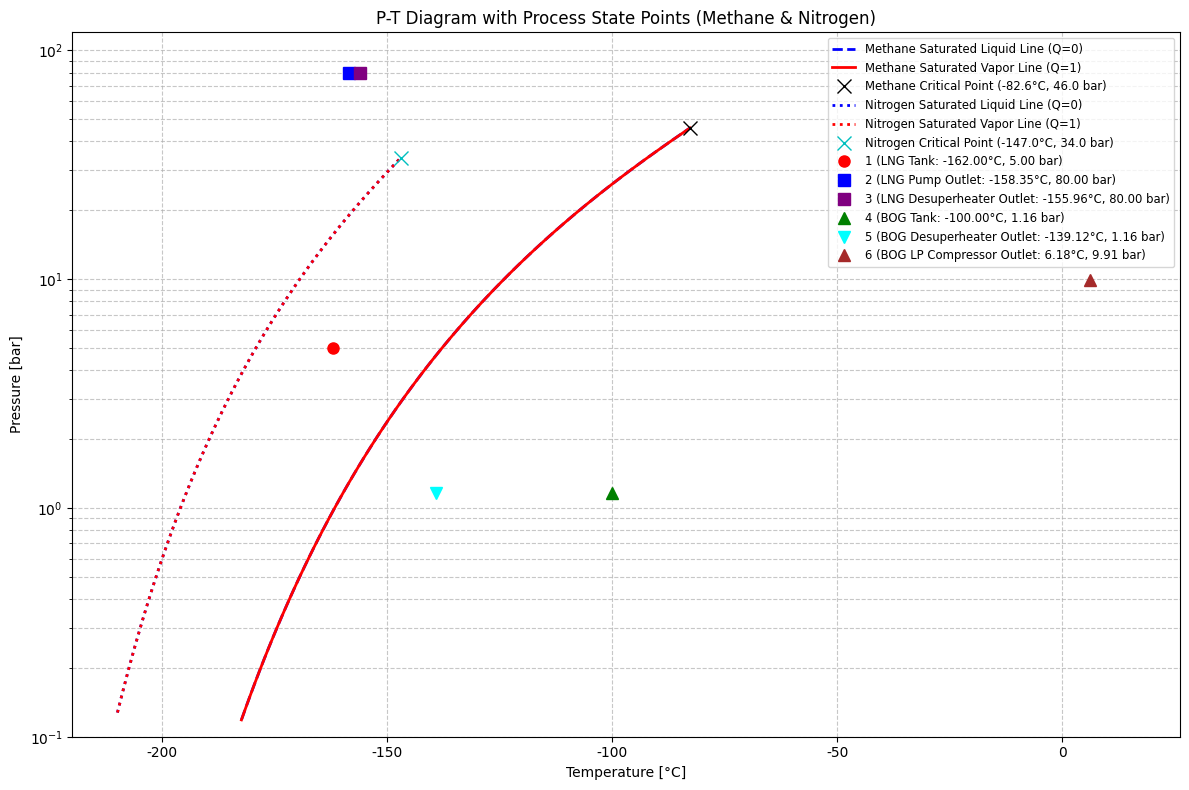

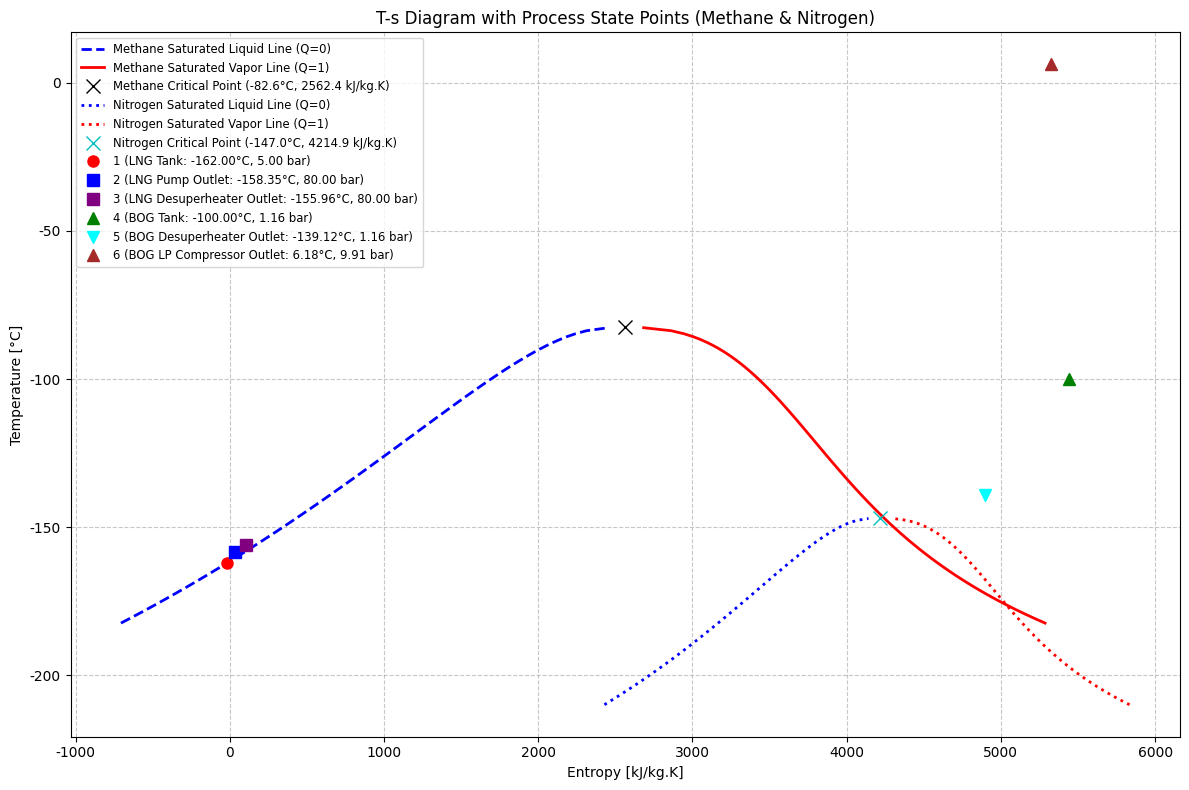

In [26]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# --- Configure matplotlib for default English font support ---
# Ensure unicode minus is handled (use hyphen instead of unicode minus)
plt.rcParams['axes.unicode_minus'] = False
# Remove specific Korean font configuration to avoid errors and use default English fonts
# as requested by the user if Korean fonts cause issues.
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Liberation Sans']


# --- Methane Critical Point ---
Tc_K_methane = CP.PropsSI('Tcrit', FLUID_LNG)
Pc_Pa_methane = CP.PropsSI('Pcrit', FLUID_LNG)
Tc_C_methane = K_to_C(Tc_K_methane)
Pc_bar_methane = Pa_to_bar(Pc_Pa_methane)

# --- Methane Saturation Curve Data for P-T diagram ---
# Generate temperatures from triple point to critical point
T_triple_K_methane = CP.PropsSI('Ttriple', FLUID_LNG)
T_sat_K_values_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point for sat curve

P_sat_liquid_Pa_values_methane = []
P_sat_vapor_Pa_values_methane = []

for T_K in T_sat_K_values_methane:
    try:
        P_sat_liquid_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturation pressure for liquid (Q=0)
        P_sat_vapor_Pa_values_methane.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturation pressure for vapor (Q=1)
    except ValueError:
        P_sat_liquid_Pa_values_methane.append(np.nan) # Handle cases where P_sat might not be found
        P_sat_vapor_Pa_values_methane.append(np.nan)

P_sat_liquid_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_methane]
P_sat_vapor_bar_values_methane = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_methane]
T_sat_C_values_methane = [K_to_C(t) for t in T_sat_K_values_methane]

# --- Nitrogen Critical Point ---
FLUID_NITROGEN = 'Nitrogen'
Tc_K_nitrogen = CP.PropsSI('Tcrit', FLUID_NITROGEN)
Pc_Pa_nitrogen = CP.PropsSI('Pcrit', FLUID_NITROGEN)
Tc_C_nitrogen = K_to_C(Tc_K_nitrogen)
Pc_bar_nitrogen = Pa_to_bar(Pc_Pa_nitrogen)

# --- Nitrogen Saturation Curve Data for P-T diagram ---
T_triple_K_nitrogen = CP.PropsSI('Ttriple', FLUID_NITROGEN)
T_sat_K_values_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100)

P_sat_liquid_Pa_values_nitrogen = []
P_sat_vapor_Pa_values_nitrogen = []

for T_K in T_sat_K_values_nitrogen:
    try:
        P_sat_liquid_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        P_sat_vapor_Pa_values_nitrogen.append(CP.PropsSI('P', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        P_sat_liquid_Pa_values_nitrogen.append(np.nan)
        P_sat_vapor_Pa_values_nitrogen.append(np.nan)

P_sat_liquid_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_liquid_Pa_values_nitrogen]
P_sat_vapor_bar_values_nitrogen = [Pa_to_bar(p) if not np.isnan(p) else np.nan for p in P_sat_vapor_Pa_values_nitrogen]
T_sat_C_values_nitrogen = [K_to_C(t) for t in T_sat_K_values_nitrogen]

# --- Define the state points to plot (aligned with df_streams_full) ---
state_points = [
    # 1. LNG Tank
    {'label': f"1 (LNG Tank: {results['LNG_TANK_T_C']:.2f}°C, {results['LNG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['LNG_TANK_T_C'], 'P_bar': results['LNG_TANK_P_BAR'], 'marker': 'o', 'color': 'red'},
    # 2. LNG Pump Outlet (Calculated)
    {'label': f"2 (LNG Pump Outlet: {results['LNG_PUMP_OUT_CALC_T_C']:.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['LNG_PUMP_OUT_CALC_T_C'], 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 's', 'color': 'blue'},
    # 3. LNG Desuperheater Outlet
    {'label': f"3 (LNG Desuperheater Outlet: {results['LNG_PUMP_OUT_HEATED_T_C']:.2f}°C, {results['LNG_PUMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['LNG_PUMP_OUT_HEATED_T_C'], 'P_bar': results['LNG_PUMP_OUT_P_BAR'], 'marker': 's', 'color': 'purple'},
    # 4. BOG Tank
    {'label': f"4 (BOG Tank: {results['BOG_TANK_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_TANK_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': '^', 'color': 'green'},
    # 5. BOG Desuperheater Outlet
    {'label': f"5 (BOG Desuperheater Outlet: {results['BOG_DESUPERHEATER_OUT_T_C']:.2f}°C, {results['BOG_TANK_P_BAR']:.2f} bar)",
     'T_C': results['BOG_DESUPERHEATER_OUT_T_C'], 'P_bar': results['BOG_TANK_P_BAR'], 'marker': 'v', 'color': 'cyan'},
    # 6. BOG LP Compressor Outlet
    {'label': f"6 (BOG LP Compressor Outlet: {results['BOG_COMP_OUT_T_C']:.2f}°C, {results['BOG_COMP_OUT_P_BAR']:.2f} bar)",
     'T_C': results['BOG_COMP_OUT_T_C'], 'P_bar': results['BOG_COMP_OUT_P_BAR'], 'marker': '^', 'color': 'brown'}
]

# --- Plotting the P-T Diagram ---
fig_pt_diag = plt.figure(figsize=(12, 8)) # Assign to a variable for potential saving, larger figure

# Methane Saturation Curves
plt.plot(T_sat_C_values_methane, P_sat_liquid_bar_values_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(T_sat_C_values_methane, P_sat_vapor_bar_values_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')
plt.plot(Tc_C_methane, Pc_bar_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {Pc_bar_methane:.1f} bar)')

# Nitrogen Saturation Curves
plt.plot(T_sat_C_values_nitrogen, P_sat_liquid_bar_values_nitrogen, 'b:', linewidth=2, label='Nitrogen Saturated Liquid Line (Q=0)') # Dotted line for Nitrogen
plt.plot(T_sat_C_values_nitrogen, P_sat_vapor_bar_values_nitrogen, 'r:', linewidth=2, label='Nitrogen Saturated Vapor Line (Q=1)')   # Dotted line for Nitrogen
plt.plot(Tc_C_nitrogen, Pc_bar_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {Pc_bar_nitrogen:.1f} bar)') # Cyan cross for Nitrogen critical point

for point in state_points:
    plt.plot(point['T_C'], point['P_bar'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('P-T Diagram with Process State Points (Methane & Nitrogen)')
plt.xlabel('Temperature [°C]')
plt.ylabel('Pressure [bar]')
plt.yscale('log') # Pressure often spans several orders of magnitude, so log scale is useful
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.xlim(min(min(T_sat_C_values_methane), min(T_sat_C_values_nitrogen)) - 10, max([p['T_C'] for p in state_points]) + 20)
plt.ylim(0.1, max(Pc_bar_methane, Pc_bar_nitrogen, max([p['P_bar'] for p in state_points])) * 1.5)
plt.tight_layout()
plt.show()


# --- Methane Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_methane = np.linspace(T_triple_K_methane + 0.1, Tc_K_methane - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_methane = []
s_sat_vapor_values_methane = []

for T_K in T_sat_K_values_ts_methane:
    try:
        # For saturated liquid and vapor entropy, we specify T and Q
        s_sat_liquid_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_LNG)) # Saturated liquid entropy (Q=0)
        s_sat_vapor_values_methane.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_LNG)) # Saturated vapor entropy (Q=1)
    except ValueError:
        s_sat_liquid_values_methane.append(np.nan)
        s_sat_vapor_values_methane.append(np.nan)

T_sat_C_values_ts_methane = [K_to_C(t) for t in T_sat_K_values_ts_methane]

# --- Nitrogen Saturation Curve Data for T-s diagram ---
T_sat_K_values_ts_nitrogen = np.linspace(T_triple_K_nitrogen + 0.1, Tc_K_nitrogen - 0.1, 100) # Avoid exact critical point

s_sat_liquid_values_nitrogen = []
s_sat_vapor_values_nitrogen = []

for T_K in T_sat_K_values_ts_nitrogen:
    try:
        s_sat_liquid_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 0, FLUID_NITROGEN))
        s_sat_vapor_values_nitrogen.append(CP.PropsSI('Smass', 'T', T_K, 'Q', 1, FLUID_NITROGEN))
    except ValueError:
        s_sat_liquid_values_nitrogen.append(np.nan)
        s_sat_vapor_values_nitrogen.append(np.nan)

T_sat_C_values_ts_nitrogen = [K_to_C(t) for t in T_sat_K_values_ts_nitrogen]

# --- Calculate entropy for existing state points (assuming Methane properties for these points) ---
state_points_ts = []
for point in state_points:
    T_K_point = C_to_K(point['T_C'])
    P_Pa_point = bar_to_Pa(point['P_bar'])
    try:
        # For process points, assume FLUID_LNG (Methane) properties since the states are primarily LNG/Methane rich
        # If a point is for BOG, its entropy can be calculated with FLUID (Methane-Nitrogen mixture).
        # However, for plotting on pure Methane T-s diagram, we'd use Methane's pure component entropy at that T,P.
        # To keep it simple and consistent with the T-s plot for Methane, we'll calculate entropy based on FLUID_LNG.
        # For BOG points, calculating entropy with FLUID_LNG (pure Methane) is an approximation for visualization on a Methane diagram.
        s_point = s_TP(T_K_point, P_Pa_point, FLUID_LNG)
    except ValueError:
        s_point = np.nan # Handle cases where entropy might not be found
    state_points_ts.append(
        {
            'label': point['label'],
            'T_C': point['T_C'],
            's': s_point,
            'marker': point['marker'],
            'color': point['color'],
        }
    )

# --- Plotting the T-s Diagram ---
fig_ts_diag = plt.figure(figsize=(12, 8))

# Methane Saturation Curves
plt.plot(s_sat_liquid_values_methane, T_sat_C_values_ts_methane, 'b--', linewidth=2, label='Methane Saturated Liquid Line (Q=0)')
plt.plot(s_sat_vapor_values_methane, T_sat_C_values_ts_methane, 'r-', linewidth=2, label='Methane Saturated Vapor Line (Q=1)')

# Methane Critical Point
s_crit_methane = s_TP(Tc_K_methane, Pc_Pa_methane, FLUID_LNG)
plt.plot(s_crit_methane, Tc_C_methane, 'kx', markersize=10, label=f'Methane Critical Point ({Tc_C_methane:.1f}°C, {s_crit_methane:.1f} kJ/kg.K)')

# Nitrogen Saturation Curves
plt.plot(s_sat_liquid_values_nitrogen, T_sat_C_values_ts_nitrogen, 'b:', linewidth=2, label='Nitrogen Saturated Liquid Line (Q=0)')
plt.plot(s_sat_vapor_values_nitrogen, T_sat_C_values_ts_nitrogen, 'r:', linewidth=2, label='Nitrogen Saturated Vapor Line (Q=1)')

# Nitrogen Critical Point
s_crit_nitrogen = s_TP(Tc_K_nitrogen, Pc_Pa_nitrogen, FLUID_NITROGEN)
plt.plot(s_crit_nitrogen, Tc_C_nitrogen, 'cx', markersize=10, label=f'Nitrogen Critical Point ({Tc_C_nitrogen:.1f}°C, {s_crit_nitrogen:.1f} kJ/kg.K)')

# Plot Process State Points
for point in state_points_ts:
    if not np.isnan(point['s']):
        plt.plot(point['s'], point['T_C'], point['marker'], color=point['color'], markersize=8, label=point['label'])

plt.title('T-s Diagram with Process State Points (Methane & Nitrogen)')
plt.xlabel('Entropy [kJ/kg.K]')
plt.ylabel('Temperature [°C]')
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.legend(loc='best', fontsize='small')
plt.tight_layout()
plt.show()

In [ ]:
# @title
import pandas as pd

# 동력 소모량 데이터를 위한 리스트 생성
power_data = []

power_data.append({
    "장비": "LNG 펌프",
    "동력 소모량 [MW]": results["LNG_PUMP_POWER_MW"],
    "효율 / 유용도": params["pump_eta"]
})
power_data.append({
    "장비": "BOG 압축기",
    "동력 소모량 [MW]": results["BOG_COMP_POWER_MW"],
    "효율 / 유용도": params["comp_eta"]
})
power_data.append({
    "장비": "디슈퍼히터",
    "동력 소모량 [MW]": "N/A", # 열교환기는 동력을 소모하지 않으므로 N/A
    "효율 / 유용도": params["desuperheater_effectiveness"]
})

# 총 동력 소모량 추가
power_data.append({
    "장비": "총 시스템 동력",
    "동력 소모량 [MW]": results["TOTAL_POWER_MW"],
    "효율 / 유용도": "N/A" # 총 시스템 동력은 개별 효율을 갖지 않음
})

# 데이터프레임 생성
df_power_summary = pd.DataFrame(power_data)

print("\n=== 장비 동력 소모량 요약 ===")
display(df_power_summary.round(3))


=== 장비 동력 소모량 요약 ===


,장비,동력 소모량 [MW],효율 / 유용도
0,LNG 펌프,1.527778,0.75
1,BOG 압축기,2.201008,0.665
2,디슈퍼히터,N/A,0.7
3,총 시스템 동력,3.728785,N/A


In [21]:
mermaid_diagram_code = """graph TD
    subgraph LNG Stream
        A[LNG 탱크] --> B(LNG 펌프)
        B --> C{디슈퍼히터 (LNG 냉각 측)}
    end

    subgraph BOG Stream
        D[BOG 탱크] --> E{디슈퍼히터 (BOG 가열 측)}
        E --> F(BOG 저압 압축기)
    end

    C -- 냉각된 LNG --> G[LNG 검토 종료]
    F -- 압축된 BOG --> H[BOG 검토 종료]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style D fill:#f9f,stroke:#333,stroke-width:2px
    style G fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
"""

print("Mermaid diagram code generated.")

Mermaid diagram code generated.


## Simplified LNG Vaporization Process System Diagram

Google Colab's Markdown cells do not directly render Mermaid diagrams as images. To view the visualized diagram, you can paste the code below into an online tool like Mermaid Live Editor (https://mermaid.live/).

```mermaid
graph TD
    subgraph LNG Stream
        A[LNG Tank] --> B(LNG Pump)
        B --> C{Desuperheater (LNG Cooling Side)}
    end

    subgraph BOG Stream
        D[BOG Tank] --> E{Desuperheater (BOG Heating Side)}
        E --> F(BOG LP Compressor)
    end

    C -- Cooled LNG --> G[LNG Process End]
    F -- Compressed BOG --> H[BOG Process End]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style D fill:#f9f,stroke:#333,stroke-width:2px
    style G fill:#f9f,stroke:#333,stroke-width:2px
    style H fill:#f9f,stroke:#333,stroke-width:2px
```